The contents of this notebook were created with assistance from Claude generative AI.

# Advanced Failure Analysis — Per-Record Interpretability (Tuned ModernBERT)

Enter **one gold record id** (a `row_id` like `r04449`, `r01980`, `r03464`) and this notebook
explains *why the tuned ModernBERT predicted what it did* for that record, using three
complementary attribution methods read side-by-side — each computed toward **both** the predicted
class and the true class, so you can see which words pushed the model toward its (wrong) prediction
and which supported the correct label:

| Section | What it does |
|---|---|
| **0** | Per-class **recall** (gold set, frozen model — no retraining) + train-pool class frequency |
| **1** | The record's prediction, confidence, true label, context, target |
| **2** | **LIME** word weights toward **both** the predicted and the true class |
| **3** | **SHAP** signed per-token contributions toward all 4 classes |
| **4** | **Captum** Integrated Gradients — tokens pushing toward **pred** vs **true** |
| **5** | LIME vs SHAP vs Captum aligned at **whole-word** level, **pred vs true** — two comparison charts |
| **6** | The record's true-class train frequency + per-class recall, side-by-side |

**Frozen model, no retraining.** We load the *same* artifact that produced the deployment predictions
(`saved_models/tuned/modernbert`) with its `inference_config.json` (**max_len 512, left-truncation**),
so every prediction here matches `stance_predictions_modernbert_tuned.parquet`. Gold construction, the
stance map, and the 4 labels all come from `m5_common.load_frames()` (reused verbatim).

> **Kernel: `mads-m2-eval`** (CUDA torch + transformers + shap + captum — the same env as
> `modernbert_token_ablation.ipynb`). **One extra dependency** not in `requirements.txt`: `lime`.
> Install it into that env once: `uv pip install lime`.

## Setup — imports, frozen tuned ModernBERT, and `predict_proba`

In [11]:
import os, sys, json, warnings
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

P15 = os.getcwd()
P16 = os.getcwd()
if P15 not in sys.path:
    sys.path.insert(0, P15)
import m5_common as m5   # CPU-safe import; torch/transformers are lazy inside its functions

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

LABELS = m5.LABELS                      # ["anti", "neutral", "pro", "off-topic"]
lab2i, i2lab = m5.lab2i, m5.i2lab
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── the frozen tuned ModernBERT — exactly the deployment inference config ──
MB  = m5.model_path("tuned", "ModernBERT")
cfg = json.loads((MB / "inference_config.json").read_text())
MAX_LEN = cfg.get("max_len", 512)
tok = AutoTokenizer.from_pretrained(MB)
tok.truncation_side = cfg.get("truncation_side", "left")   # keep the [TARGET] (end) when truncating
model = AutoModelForSequenceClassification.from_pretrained(MB).to(DEVICE).eval()

def _ac():
    return torch.autocast("cuda", dtype=torch.bfloat16) if DEVICE == "cuda" else nullcontext()

@torch.no_grad()
def predict_proba(texts):
    '''str | list[str] -> (n, 4) softmax in LABELS order. The single inference path used everywhere
    below (Section 0 gold recall, the record prediction, LIME, and SHAP). Frozen tuned model, 512
    tokens, left-truncation — identical to the saved deployment predictions.'''
    if isinstance(texts, str):
        texts = [texts]
    texts = [str(t) for t in texts]
    out = []
    for i in range(0, len(texts), 64):
        enc = tok(texts[i:i + 64], truncation=True, max_length=MAX_LEN, padding=True,
                  return_tensors="pt").to(DEVICE)
        with _ac():
            logits = model(**enc).logits.float()
        out.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.concatenate(out, axis=0)

print("loaded tuned ModernBERT :", MB)
print("device                  :", DEVICE)
print("labels                  :", LABELS)
print("max_len / truncation    :", MAX_LEN, "/", tok.truncation_side)
print("hyperparams (from cfg)  :", cfg.get("hyperparams"))

Loading weights: 100%|██████████| 138/138 [00:00<00:00, 5207.03it/s]


loaded tuned ModernBERT : saved_models\tuned\modernbert
device                  : cuda
labels                  : ['anti', 'neutral', 'pro', 'off-topic']
max_len / truncation    : 512 / left
hyperparams (from cfg)  : {'lr': 4.991029159030355e-05, 'weight_decay': 0.01622890417738726, 'warmup_ratio': 0.038038895602179296, 'epochs': 4, 'class_weighted': True}


## Section 0 — Per-class recall (frozen model, no retraining) + train-pool frequency

We need per-class recall **without retraining**. The gold set (301 human-labeled records — the only
place true labels live, and the population the entered record belongs to) is run through the *frozen*
tuned model and recall is computed per class. This is deterministic and apples-to-apples with the
gold-stage numbers in `gold_results.csv`. Results are cached to `gold_per_class_recall.csv`, so the
cell **loads** them on re-runs instead of recomputing.

> An out-of-fold *CV* per-class recall would instead require re-running the 5 folds. If you ever want
> that, retrain with `m5_common`'s frozen settings (`SEED=42`, `StratifiedGroupKFold` on `link_id`,
> the tuned hyperparameters in `tuned_hyperparams.json`) — but it is **not** needed for failure
> analysis, and gold recall is the more relevant reference here.

In [12]:
from sklearn.metrics import recall_score

RECALL_CSV = Path(P16) / "gold_per_class_recall.csv"

frames   = m5.load_frames()
train_df = frames["df"]
gold     = frames["gold_text"].reset_index(drop=True)

# train-pool class frequency (used here and again in Section 6)
train_freq = train_df["label"].value_counts().reindex(LABELS).fillna(0).astype(int)

if RECALL_CSV.exists():
    recall_tbl = pd.read_csv(RECALL_CSV, index_col=0)
    print("loaded cached per-class recall ->", RECALL_CSV.name)
else:
    gold_proba = predict_proba(gold["text"].tolist())
    gold_pred  = pd.Series(gold_proba.argmax(1)).map(i2lab).to_numpy()
    gold_true  = gold["label"].to_numpy()
    rec = recall_score(gold_true, gold_pred, labels=LABELS, average=None, zero_division=0)
    sup = pd.Series(gold_true).value_counts().reindex(LABELS).fillna(0).astype(int)
    recall_tbl = pd.DataFrame({"gold_support": sup.values, "recall": rec}, index=LABELS)
    recall_tbl.to_csv(RECALL_CSV)
    print(f"computed per-class recall on {len(gold)} gold records (frozen tuned model, no retraining) ->",
          RECALL_CSV.name)

recall_tbl = recall_tbl.assign(train_freq=train_freq.reindex(LABELS).values)
display(recall_tbl.round(3))

loaded cached per-class recall -> gold_per_class_recall.csv


,gold_support,recall,train_freq
anti,53,0.623,1292
neutral,189,0.201,933
pro,38,0.737,1857
off-topic,21,0.048,748


## Section 1 — Enter a record · prediction, confidence, true label, context, target

Set `RECORD_ID` to any gold `row_id`. Everything below this cell re-runs against it.

In [13]:
RECORD_ID = "r04449"   # <-- enter any gold row_id, e.g. r04449, r01980, r03464

hit = gold[gold["row_id"] == RECORD_ID]
assert len(hit) == 1, (f"{RECORD_ID!r} not found in gold set (matched {len(hit)}). "
                       f"Valid ids are gold row_ids like r04449. "
                       f"e.g. {sorted(gold['row_id'].sample(5, random_state=0))}")
rec  = hit.iloc[0]
text = str(rec["text"])

proba    = predict_proba([text])[0]
pred_idx = int(proba.argmax()); pred_lab = i2lab[pred_idx]; conf = float(proba[pred_idx])
true_lab = rec["label"];        true_idx = lab2i[true_lab]
is_wrong = pred_lab != true_lab
margin   = conf - float(proba[true_idx])     # >0 = confidently wrong

print(f"record       : {RECORD_ID}   (reddit_id={rec.get('reddit_id')}, subreddit={rec.get('subreddit')}, kind={rec.get('kind')})")
print(f"TRUE  label  : {true_lab}")
print(f"PRED  label  : {pred_lab}    --> {'WRONG' if is_wrong else 'CORRECT'}")
print(f"confidence   : {conf:.3f}")
print(f"P(true)      : {proba[true_idx]:.3f}     margin(pred - true) = {margin:+.3f}")

display(pd.DataFrame([proba], columns=LABELS, index=["P"]).round(3))

print("\n--- CONTEXT ---")
print((str(rec["context"]).strip() or "(none — top-level post)"))
print("\n--- TARGET ---")
print(str(rec["target"]).strip())
print("\n--- MODEL INPUT (text, fed @512 left-trunc) ---")
print(text)

# Sections 2-5 attribute toward BOTH the predicted class and the true class
TARGET_CLASS = pred_idx   # kept for back-compat; the cells below use pred_idx / true_idx directly
print(f"\n[attribution] toward PRED='{i2lab[pred_idx]}'  and  TRUE='{i2lab[true_idx]}'"
      + ("  (same class — record is CORRECT)" if pred_idx == true_idx else ""))

record       : r04449   (reddit_id=l8n2t2o, subreddit=fuckcars, kind=comment)
TRUE  label  : pro
PRED  label  : anti    --> WRONG
confidence   : 0.989
P(true)      : 0.011     margin(pred - true) = +0.978


,anti,neutral,pro,off-topic
P,0.989,0.0,0.011,0.0



--- CONTEXT ---
[POST · OP] The first of these that I've seen in midtown Manhattan
[A] I wouldn't trust speed humps to help much. Never felt the need to slow down for them even in old Corolla. Especially unhelpful with all these damn SUVers and Pickup Truckers. Super low one anyway.

--- TARGET ---
[OP] I'll take what I can get, the "pause" on congestion pricing has me grasping at straws for relief.

--- MODEL INPUT (text, fed @512 left-trunc) ---
[CONTEXT]
[POST · OP] The first of these that I've seen in midtown Manhattan
[A] I wouldn't trust speed humps to help much. Never felt the need to slow down for them even in old Corolla. Especially unhelpful with all these damn SUVers and Pickup Truckers. Super low one anyway.

[TARGET]
[OP] I'll take what I can get, the "pause" on congestion pricing has me grasping at straws for relief.

[attribution] toward PRED='anti'  and  TRUE='pro'


## Section 2 — LIME: word weights toward the predicted AND true class

`LimeTextExplainer` perturbs the input by deleting words, calls the model's `predict_proba` on each
perturbation, and fits a local linear model. We explain **both** the predicted class and the true
class, so you can read which words pulled the model toward its (wrong) `pred` and which supported the
`true` label. Teal pushes toward that class, coral pushes away. `bow=False` keeps word positions so
repeated words are handled in place.

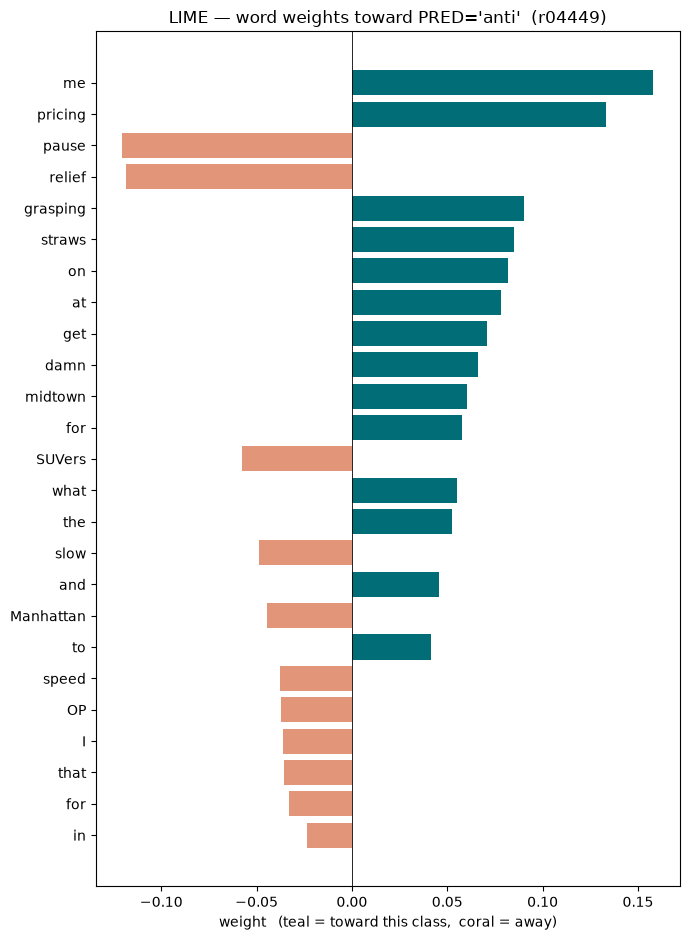

LIME toward PRED='anti':


,token,lime_weight
0,me,0.1581
1,pricing,0.1332
2,pause,-0.1204
3,relief,-0.1183
4,grasping,0.0901
5,straws,0.0850
6,on,0.0819
7,at,0.0783
8,get,0.0707
9,damn,0.0663


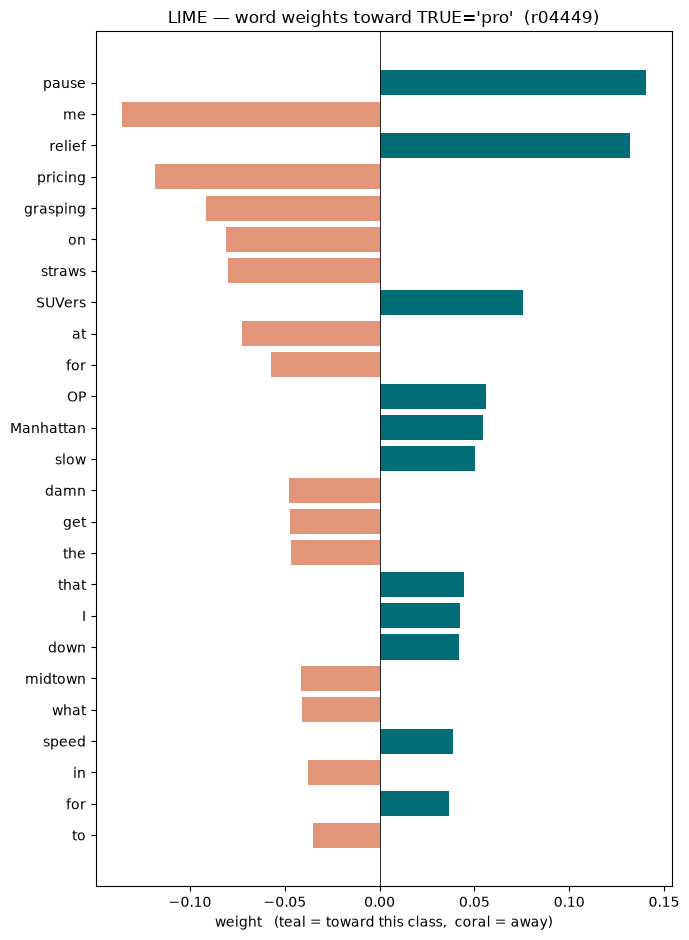

LIME toward TRUE='pro':


,token,lime_weight
0,pause,0.1403
1,me,-0.1359
2,relief,0.1321
3,pricing,-0.1186
4,grasping,-0.0916
5,on,-0.0811
6,straws,-0.0800
7,SUVers,0.0755
8,at,-0.0725
9,for,-0.0574


In [14]:
from lime.lime_text import LimeTextExplainer

explainer_lime = LimeTextExplainer(class_names=LABELS, bow=False, random_state=m5.SEED)
_lime_labels = sorted({pred_idx, true_idx})            # one explanation, both classes
exp = explainer_lime.explain_instance(
    text, predict_proba, num_features=25, labels=_lime_labels, num_samples=1000)

lime_pred_df = pd.DataFrame(exp.as_list(label=pred_idx), columns=["token", "lime_weight"])
lime_true_df = pd.DataFrame(exp.as_list(label=true_idx), columns=["token", "lime_weight"])

def _lime_plot(df, cls_lab, kind):
    plt.figure(figsize=(7, 0.34 * len(df) + 1))
    colors = ["#006D77" if w > 0 else "#E29578" for w in df["lime_weight"]]
    plt.barh(range(len(df)), df["lime_weight"], color=colors)
    plt.yticks(range(len(df)), df["token"]); plt.gca().invert_yaxis()
    plt.axvline(0, color="k", lw=0.6)
    plt.title(f"LIME — word weights toward {kind}='{cls_lab}'  ({RECORD_ID})")
    plt.xlabel("weight   (teal = toward this class,  coral = away)")
    plt.tight_layout(); plt.show()

_lime_plot(lime_pred_df, pred_lab, "PRED")
print(f"LIME toward PRED='{pred_lab}':"); display(lime_pred_df.round(4))
if true_idx != pred_idx:
    _lime_plot(lime_true_df, true_lab, "TRUE")
    print(f"LIME toward TRUE='{true_lab}':"); display(lime_true_df.round(4))

## Section 3 — SHAP: signed per-token contributions toward all 4 classes

`shap.Explainer` with `shap.maskers.Text(tokenizer)` (Partition SHAP) gives signed contributions for
**every token toward every class**. One bar plot per class; the **PRED** and **TRUE** classes are
annotated. Positive (teal) = the token pushed the model toward that class; negative (coral) = away.

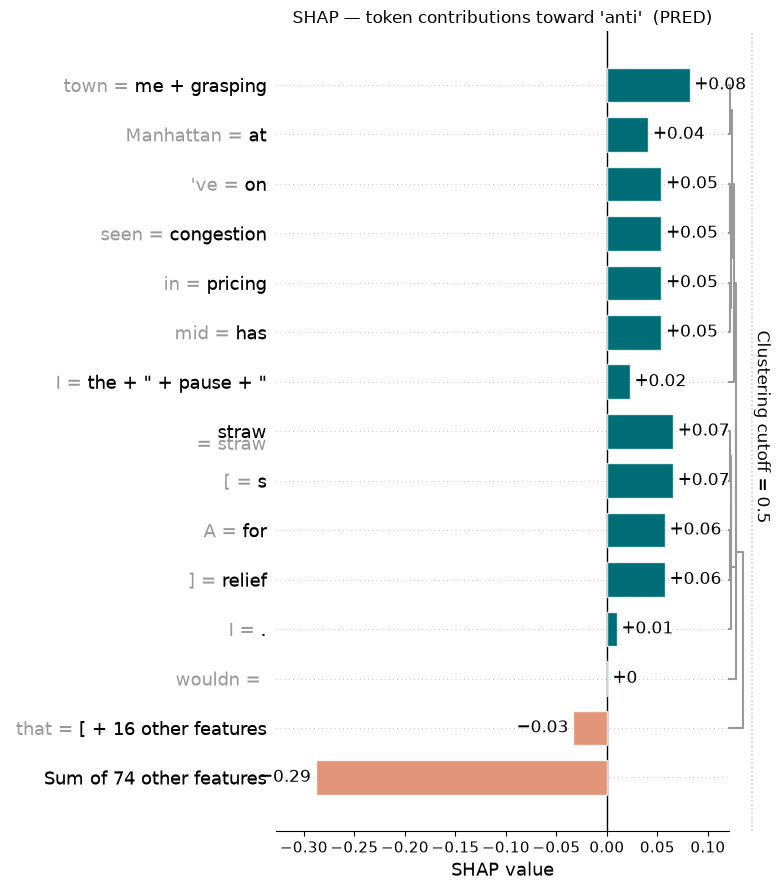

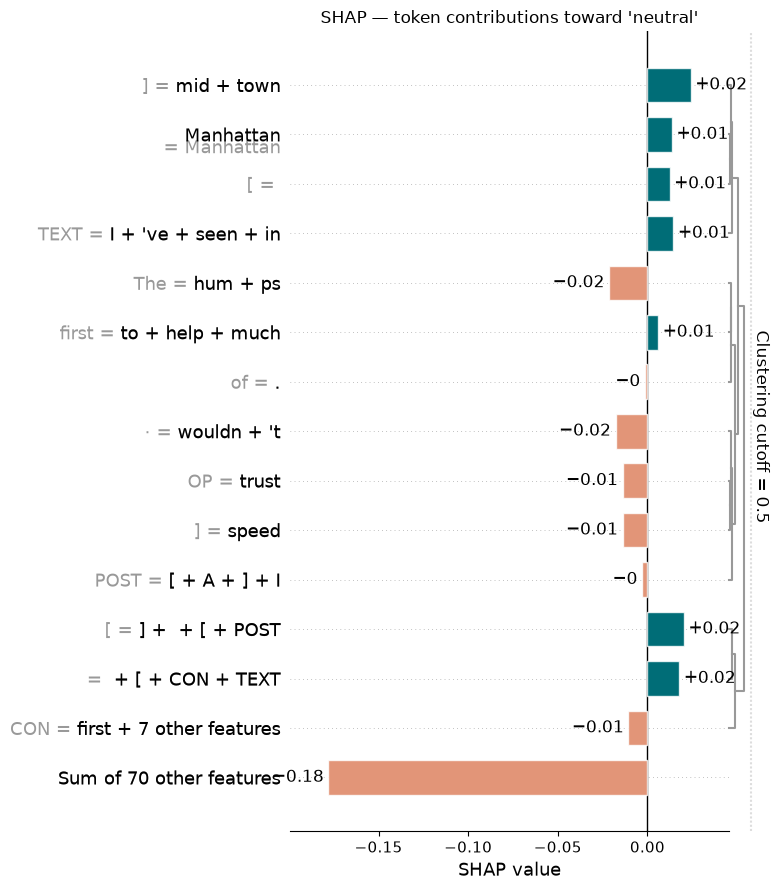

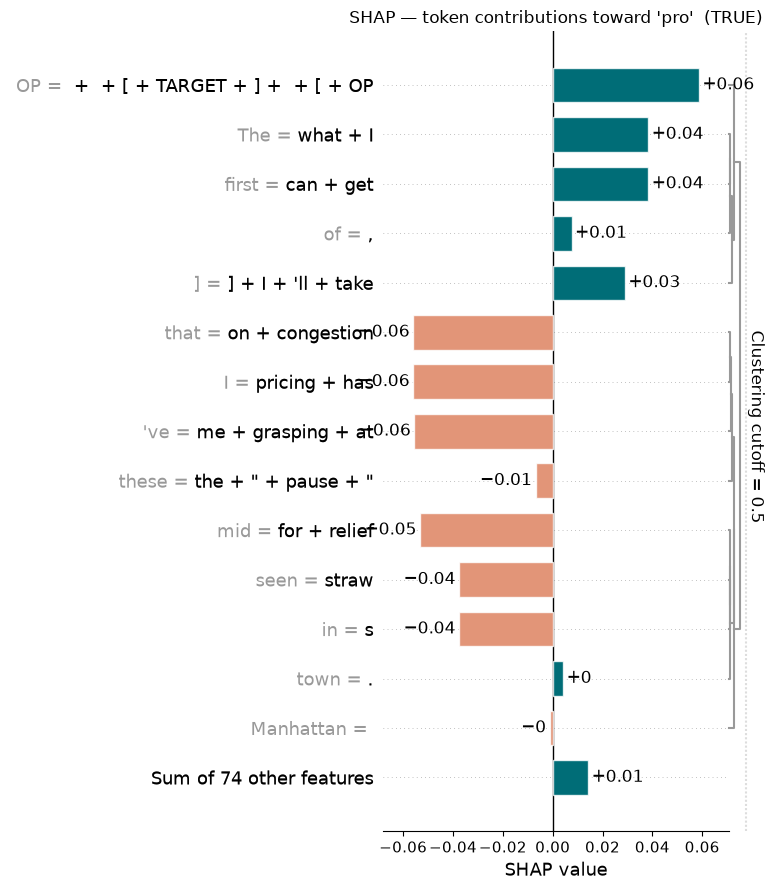

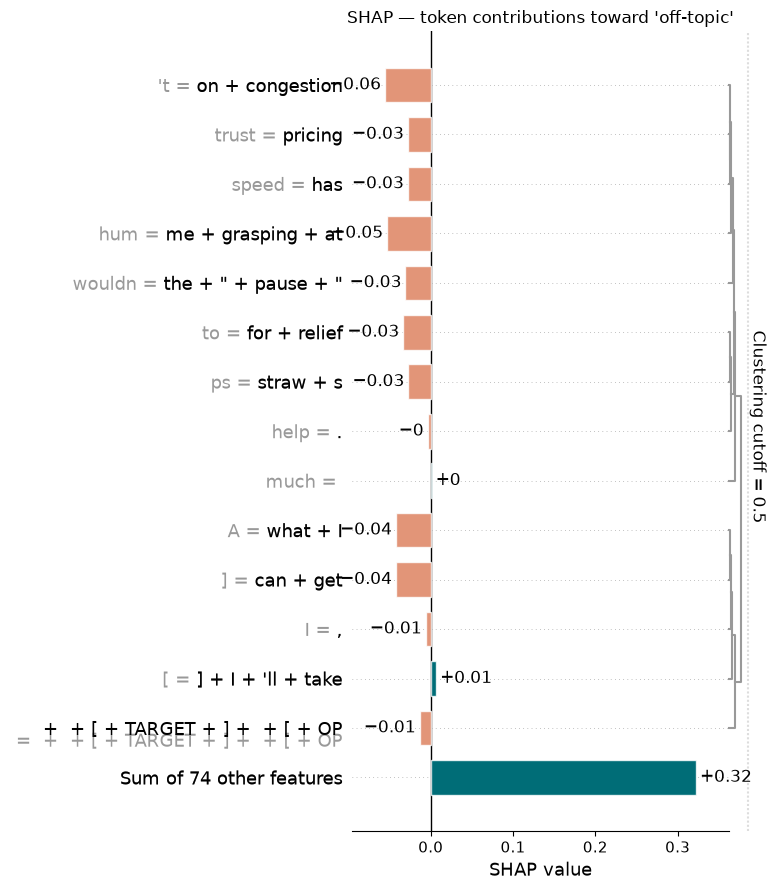

In [15]:
import shap

masker = shap.maskers.Text(tok)
explainer_shap = shap.Explainer(predict_proba, masker, output_names=LABELS)
sv = explainer_shap([text])          # Explanation, shape (1, n_tokens, 4)

COLOR_POS = "#006D77"
COLOR_NEG = "#E29578"

for i, lbl in enumerate(LABELS):
    tag = "  (PRED)" if i == pred_idx else ("  (TRUE)" if i == true_idx else "")
    shap.plots.bar(sv[0, :, i], max_display=15, show=False)
    ax = plt.gca()
    for patch in ax.patches:
        patch.set_facecolor(COLOR_POS if patch.get_width() > 0 else COLOR_NEG)
    for t in ax.texts:
        t.set_color("black")
    plt.title(f"SHAP — token contributions toward '{lbl}'{tag}")
    plt.tight_layout(); plt.show()

# inline colored text view toward the predicted class (renders in classic/JupyterLab)
try:
    shap.plots.text(sv[0, :, pred_idx])
except Exception as e:
    print("(shap.plots.text needs a JS-enabled frontend; bar plots above are the static view.)", e)

## Section 4 — Captum Integrated Gradients: tokens pushing toward PRED vs TRUE

`LayerIntegratedGradients` on the embedding layer attributes a class logit back to the input tokens
(baseline = `[PAD]`). We run it **twice** — toward the predicted class and toward the true class — so
positive bars show which whole words pushed the model toward `pred` (its mistake) and which would have
supported `true`. Subword pieces are mean-pooled to whole words and normalized, as in
`attribute_tokens.py`. Set `TARGET_SPAN_ONLY=True` to restrict to the `[TARGET]` span (the author's
own text, excluding quoted context).

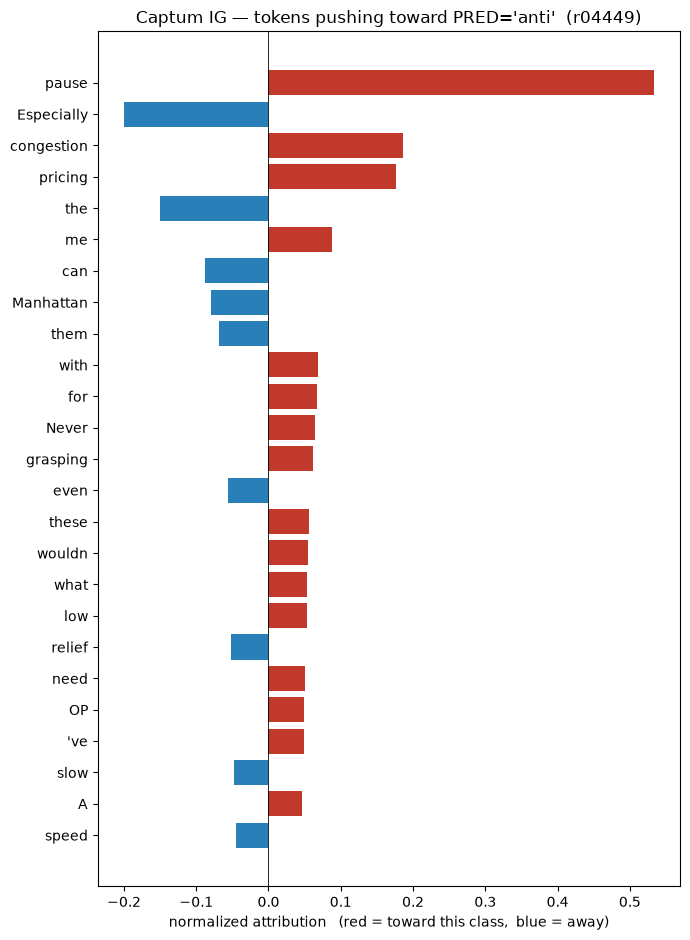

Captum toward PRED='anti':


,token,captum_attr
58,pause,0.5327
36,Especially,-0.1997
60,congestion,0.1860
61,pricing,0.1762
57,the,-0.1499
63,me,0.0880
55,can,-0.0875
12,Manhattan,-0.0798
31,them,-0.0690
38,with,0.0683


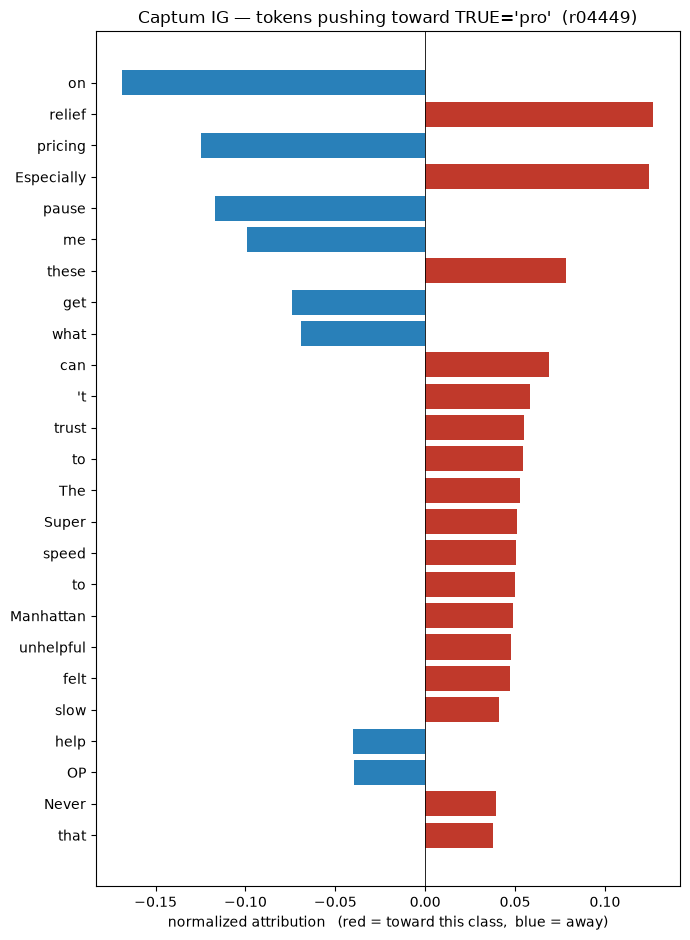

Captum toward TRUE='pro':


,token,captum_attr
59,on,-0.1685
68,relief,0.1270
61,pricing,-0.1250
36,Especially,0.1246
58,pause,-0.1168
63,me,-0.0989
40,these,0.0781
56,get,-0.0740
53,what,-0.0694
55,can,0.0689


In [16]:
from captum.attr import LayerIntegratedGradients

ref_id = tok.pad_token_id if tok.pad_token_id is not None else tok.cls_token_id
lig = LayerIntegratedGradients(
    lambda ids, am, t: model(input_ids=ids, attention_mask=am).logits[:, t],
    model.get_input_embeddings())

_MARKERS = ("[CONTEXT]", "[TARGET]", "[OP]")

def lig_words(text, target_class, n_steps=48, ibs=32, target_span_only=False):
    '''Word-level IG attribution toward `target_class`. Returns DataFrame[token, captum_attr].'''
    text = str(text)   # backstop: tokenizer requires a Python str
    enc  = tok(text, return_tensors="pt", truncation=True, max_length=MAX_LEN, return_offsets_mapping=True)
    wids = enc.word_ids(0); offs = enc["offset_mapping"][0].tolist()
    ids  = enc["input_ids"].to(DEVICE); am = enc["attention_mask"].to(DEVICE)
    baseline = torch.full_like(ids, ref_id)
    with _ac():
        a = lig.attribute(inputs=ids, baselines=baseline,
                          additional_forward_args=(am, target_class),
                          n_steps=n_steps, internal_batch_size=ibs)
    a = a.float().sum(dim=-1).squeeze(0)
    a = (a / (a.norm() + 1e-12)).tolist()

    mspans = []
    for mk in _MARKERS:
        pp = text.find(mk)
        while pp != -1:
            mspans.append((pp, pp + len(mk))); pp = text.find(mk, pp + 1)
    in_marker = lambda s, e: any(s < me and ms < e for ms, me in mspans)
    tgt_start = text.find("[TARGET]") if target_span_only else -1

    agg = {}
    for wid, av, (s, e) in zip(wids, a, offs):
        if wid is None or e <= s:
            continue
        if wid not in agg:
            agg[wid] = [0.0, s, e, 0]
        agg[wid][0] += av; agg[wid][1] = min(agg[wid][1], s)
        agg[wid][2] = max(agg[wid][2], e); agg[wid][3] += 1
    rows = []
    for wid, (asum, s, e, npc) in agg.items():
        if tgt_start != -1 and s < tgt_start:
            continue
        word = text[s:e].strip()
        if not word or not any(c.isalnum() for c in word) or in_marker(s, e):
            continue
        rows.append({"token": word, "captum_attr": asum / npc})
    return pd.DataFrame(rows)

# defensive: re-fetch this record's text from gold so Section 4 is independent of earlier-cell
# globals (some plotting/explainer calls in Sections 2-3 can leave `text` in a non-str state).
rec  = gold[gold["row_id"] == RECORD_ID].iloc[0]
text = str(rec["text"])

TARGET_SPAN_ONLY = False
cap_pred = lig_words(text, pred_idx, target_span_only=TARGET_SPAN_ONLY)
cap_true = lig_words(text, true_idx, target_span_only=TARGET_SPAN_ONLY)

def _cap_plot(df, cls_lab, kind):
    top = df.reindex(df["captum_attr"].abs().sort_values(ascending=False).index).head(25)
    plt.figure(figsize=(7, 0.34 * len(top) + 1))
    colors = ["#c0392b" if w > 0 else "#2980b9" for w in top["captum_attr"]]
    plt.barh(range(len(top)), top["captum_attr"], color=colors)
    plt.yticks(range(len(top)), top["token"]); plt.gca().invert_yaxis()
    plt.axvline(0, color="k", lw=0.6)
    plt.title(f"Captum IG — tokens pushing toward {kind}='{cls_lab}'  ({RECORD_ID})")
    plt.xlabel("normalized attribution   (red = toward this class,  blue = away)")
    plt.tight_layout(); plt.show()
    return top

_cap_top_pred = _cap_plot(cap_pred, pred_lab, "PRED")
print(f"Captum toward PRED='{pred_lab}':"); display(_cap_top_pred.round(4))
if true_idx != pred_idx:
    _cap_top_true = _cap_plot(cap_true, true_lab, "TRUE")
    print(f"Captum toward TRUE='{true_lab}':"); display(_cap_top_true.round(4))

## Section 5 — LIME vs SHAP vs Captum, aligned at whole-word level (PRED vs TRUE)

The three methods are aligned on a **normalized whole-word key**: every token is lowercased and
stripped of the BPE leading-space marker (`Ġ`) and surrounding punctuation, and SHAP's subword pieces
(e.g. `straw` + `s`) are **re-merged into whole words** before the join. So each word is **one row**
with all three methods populated — fixing the duplicate / misaligned rows the raw-token join produced
(SHAP's space-prefixed subwords never matched LIME/Captum's clean words). We build the table toward
**both** the predicted and the true class and rescale each method to unit max-|value|. The two charts
show which words pushed the model toward `pred` (its mistake) versus toward `true`.

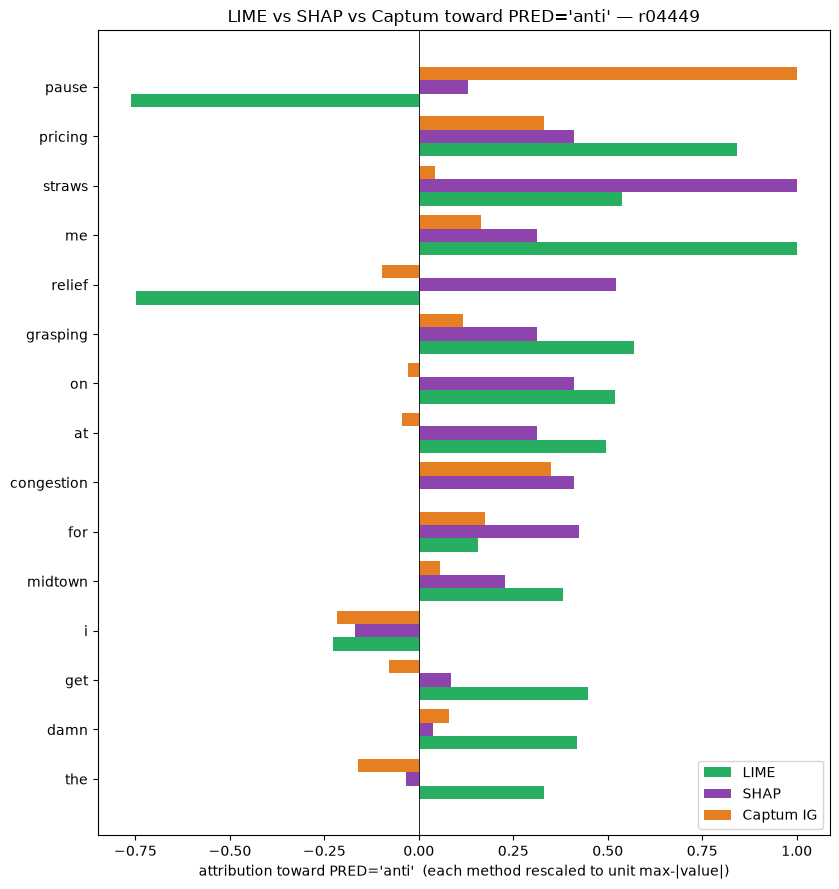

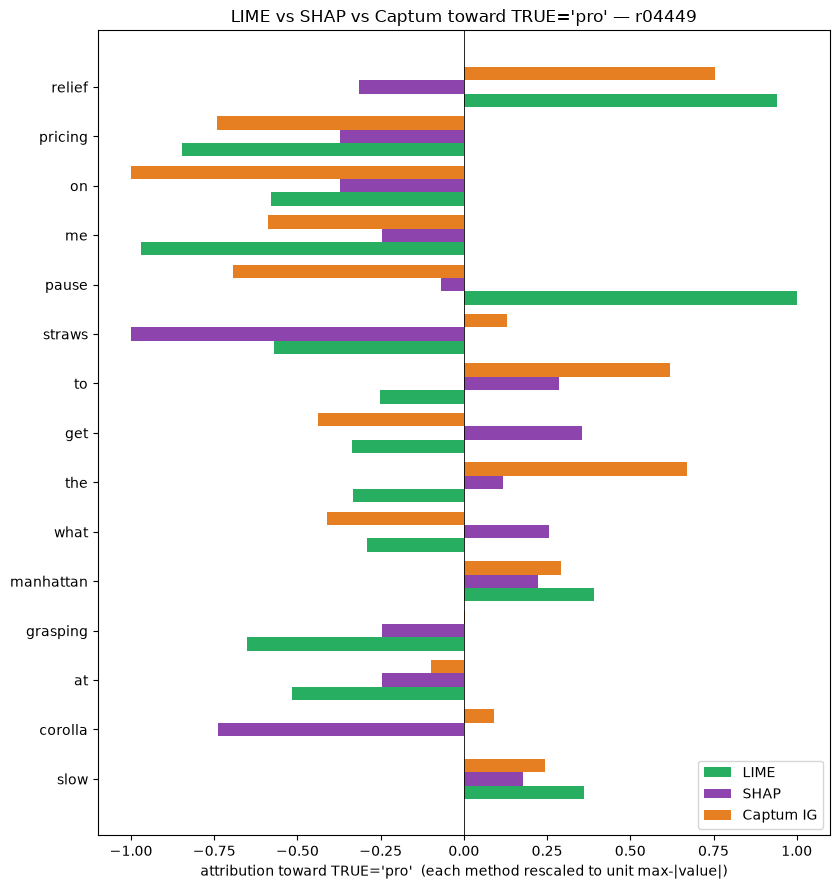

Per-word attribution toward PRED='anti' (left 3 cols) and TRUE='pro' (right 3 cols) — one row per word, all three methods aligned:


,lime_pred,shap_pred,captum_pred,lime_true,shap_true,captum_true
key,,,,,,
pause,-0.1204,0.0171,0.5327,0.1403,-0.0052,-0.1168
pricing,0.1332,0.0540,0.1762,-0.1186,-0.0280,-0.1250
relief,-0.1183,0.0683,-0.0517,0.1321,-0.0236,0.1270
me,0.1581,0.0409,0.0880,-0.1359,-0.0185,-0.0989
straws,0.0850,0.1311,0.0225,-0.0800,-0.0751,0.0218
on,0.0819,0.0540,-0.0150,-0.0811,-0.0280,-0.1685
grasping,0.0901,0.0409,0.0622,-0.0916,-0.0185,0.0007
get,0.0707,0.0113,-0.0421,-0.0471,0.0267,-0.0740
at,0.0783,0.0409,-0.0235,-0.0725,-0.0185,-0.0169


wrote attribution_compare_r04449.csv


In [17]:
import string
from functools import reduce

_BPE_SPACE  = "Ġ"                  # 'Ġ' — RoBERTa/ModernBERT word-start marker (decodes to a space)
_MARKER_KEYS = {"context", "target", "op"}

def _clean_key(s):
    '''Normalize a token to a whole-word join key: drop the Ġ/leading-space marker, surrounding
    punctuation, and lowercase. "Ġpricing"/" pricing"/"pricing." all collapse to "pricing".'''
    return str(s).replace(_BPE_SPACE, " ").strip().strip(string.punctuation).strip().lower()

def _regroup_subwords(tokens, values):
    '''Merge BPE subwords into whole words. A token that starts a new word carries a leading space
    (or the Ġ marker); continuation pieces ("straw"+"s", "I"+"\'ll") do not — they fold into the
    current word and their contributions are summed. This is what makes SHAP\'s subwords line up
    with LIME/Captum\'s whole words.'''
    out = []
    for t, v in zip(tokens, values):
        t = str(t)
        starts_word = (not out) or t[:1].isspace() or t[:1] == _BPE_SPACE
        if starts_word:
            out.append([t, float(v)])
        else:
            out[-1][0] += t
            out[-1][1] += float(v)
    return out

def _word_scores(df, col):
    '''LIME / Captum: already whole words. Normalize key, drop markers, sum duplicates.'''
    d = df[["token", col]].copy()
    d["key"] = d["token"].map(_clean_key)
    d = d[d["key"].str.contains(r"\w", regex=True) & ~d["key"].isin(_MARKER_KEYS)]
    return d.groupby("key", as_index=False)[col].sum()

def _shap_scores(sv, class_idx, col):
    '''SHAP: regroup subwords -> whole words toward class_idx, then normalize key + sum.'''
    pairs = _regroup_subwords([str(t) for t in sv.data[0]], np.asarray(sv.values[0])[:, class_idx])
    d = pd.DataFrame(pairs, columns=["token", col])
    d["key"] = d["token"].map(_clean_key)
    d = d[d["key"].str.contains(r"\w", regex=True) & ~d["key"].isin(_MARKER_KEYS)]
    return d.groupby("key", as_index=False)[col].sum()

# per-method, per-class word scores -> one wide table keyed by word
parts = [
    _word_scores(lime_pred_df, "lime_weight").rename(columns={"lime_weight": "lime_pred"}),
    _shap_scores(sv, pred_idx, "shap_pred"),
    _word_scores(cap_pred, "captum_attr").rename(columns={"captum_attr": "captum_pred"}),
    _word_scores(lime_true_df, "lime_weight").rename(columns={"lime_weight": "lime_true"}),
    _shap_scores(sv, true_idx, "shap_true"),
    _word_scores(cap_true, "captum_attr").rename(columns={"captum_attr": "captum_true"}),
]
COLS = ["lime_pred", "shap_pred", "captum_pred", "lime_true", "shap_true", "captum_true"]
merged = reduce(lambda a, b: a.merge(b, on="key", how="outer"), parts).fillna(0.0)
for c in COLS:
    merged[c + "_n"] = merged[c] / (merged[c].abs().max() + 1e-12)

def _triple_chart(kind, cls_lab, cols):
    rank = merged[[c + "_n" for c in cols]].abs().sum(1)
    top = merged.assign(_r=rank).sort_values("_r", ascending=False).head(15).iloc[::-1]
    y = np.arange(len(top)); h = 0.27
    plt.figure(figsize=(8.5, 0.5 * len(top) + 1.5))
    plt.barh(y - h, top[cols[0] + "_n"], height=h, label="LIME",      color="#27ae60")
    plt.barh(y,     top[cols[1] + "_n"], height=h, label="SHAP",      color="#8e44ad")
    plt.barh(y + h, top[cols[2] + "_n"], height=h, label="Captum IG", color="#e67e22")
    plt.yticks(y, top["key"]); plt.axvline(0, color="k", lw=0.6)
    plt.xlabel(f"attribution toward {kind}='{cls_lab}'  (each method rescaled to unit max-|value|)")
    plt.title(f"LIME vs SHAP vs Captum toward {kind}='{cls_lab}' — {RECORD_ID}")
    plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

_triple_chart("PRED", pred_lab, ["lime_pred", "shap_pred", "captum_pred"])
if true_idx != pred_idx:
    _triple_chart("TRUE", true_lab, ["lime_true", "shap_true", "captum_true"])

# combined per-word table: contribution toward PRED and toward TRUE, most important first
merged["importance"] = merged[[c + "_n" for c in COLS]].abs().sum(1)
word_tbl = merged.sort_values("importance", ascending=False).set_index("key")[COLS]
print(f"Per-word attribution toward PRED='{pred_lab}' (left 3 cols) and TRUE='{true_lab}' (right 3 cols) "
      f"— one row per word, all three methods aligned:")
display(word_tbl.head(25).round(4))
word_tbl.round(5).to_csv(Path(P16) / f"attribution_compare_{RECORD_ID}.csv")
print("wrote", f"attribution_compare_{RECORD_ID}.csv")

## Section 6 — True-class train frequency + per-class recall (side-by-side)

Closes the loop: is this failure consistent with a **systematic** weakness (a low-frequency / low-recall
class) or an isolated one? The record's true class is highlighted.

In [18]:
sec6 = recall_tbl.copy()
sec6["train_freq"] = train_freq.reindex(LABELS).values
sec6["train_pct"]  = (sec6["train_freq"] / sec6["train_freq"].sum() * 100).round(1)
sec6 = sec6[["train_freq", "train_pct", "gold_support", "recall"]]

print(f"record {RECORD_ID}:  TRUE = '{true_lab}'   PRED = '{pred_lab}'   "
      f"({'WRONG' if is_wrong else 'CORRECT'}, conf={conf:.3f})")
print(f"\nTrue class '{true_lab}':  train freq = {int(sec6.loc[true_lab, 'train_freq'])} "
      f"({sec6.loc[true_lab, 'train_pct']}% of pool)   |   gold recall = {sec6.loc[true_lab, 'recall']:.3f}")
if is_wrong:
    print(f"Pred class '{pred_lab}':  train freq = {int(sec6.loc[pred_lab, 'train_freq'])} "
          f"({sec6.loc[pred_lab, 'train_pct']}% of pool)   |   gold recall = {sec6.loc[pred_lab, 'recall']:.3f}")

def _hl(row):
    return ["background-color: #fff3cd" if row.name == true_lab else "" for _ in row]

display(sec6.round(3).style.apply(_hl, axis=1)
            .set_caption("train frequency vs gold per-class recall (true class highlighted)"))

record r04449:  TRUE = 'pro'   PRED = 'anti'   (WRONG, conf=0.989)

True class 'pro':  train freq = 1857 (38.4% of pool)   |   gold recall = 0.737
Pred class 'anti':  train freq = 1292 (26.7% of pool)   |   gold recall = 0.623


,train_freq,train_pct,gold_support,recall
anti,1292,26.700000,53,0.623000
neutral,933,19.300000,189,0.201000
pro,1857,38.400000,38,0.737000
off-topic,748,15.500000,21,0.048000
